In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
transform =  transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
train_dataset = datasets.CIFAR10(root='./data',train=True,transform=transform,download=True)
test_dataset=datasets.CIFAR10(root='./data',train=False,transform=transform,download=True)
test_dataset_visualizer=datasets.CIFAR10(root='./data',train=False,transform=transforms.Compose([transforms.ToTensor()]),download=True)
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=1000)
test_visualizer_loader=DataLoader(test_dataset_visualizer,batch_size=1000)

100%|██████████| 170M/170M [00:01<00:00, 88.3MB/s] 


In [5]:
def train_model(model,train_loader,test_loader,optimizer,loss_fn,epochs=5):
  for epoch in range(epochs):
    model.train()
    total_loss=0
    for x,y in train_loader:
      x,y=x.to(device),y.to(device)
      optimizer.zero_grad()
      logits=model(x)
      loss=loss_fn(logits,y)
      loss.backward()
      optimizer.step()
      total_loss+=loss.item()
    print(f"Epoch {epoch+1}")
    print(f"Loss : {total_loss:.4f}")
    print("Training Accuracy")
    test_model(model,train_loader)
    print("Testing Accuracy")
    test_model(model,test_loader)
def test_model(model,test_loader):
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for x,y in test_loader:
      x,y=x.to(device),y.to(device)
      logits=model(x)
      pred=logits.argmax(dim=1)
      correct+=(pred==y).sum().item()
      total+=y.size(0)
  print(f"Accuracy: {100*correct/total :.2f}")


In [7]:
for x,y in train_loader:
  x.to(device)
  print(x.shape)
  z=nn.Flatten()(x)
  print(z.shape)
  break

torch.Size([64, 3, 32, 32])
torch.Size([64, 3072])


In [ ]:
class CNN_Model(nn.Module):
  def __init__(self):
    super(CNN_Model,self).__init__()

  def forward(self):|
    pass

In [42]:
# model=CNN_Model()
model=nn.Sequential(
    nn.Flatten(),
    nn.Linear(3072,512),
    nn.ReLU(),
    nn.Linear(512,128),
    nn.ReLU(),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1284.7753
Training Accuracy
Accuracy: 49.57
Testing Accuracy
Accuracy: 47.48
Epoch 2
Loss : 1122.8588
Training Accuracy
Accuracy: 53.36
Testing Accuracy
Accuracy: 49.24
Epoch 3
Loss : 1034.3195
Training Accuracy
Accuracy: 57.00
Testing Accuracy
Accuracy: 50.88
Epoch 4
Loss : 965.8811
Training Accuracy
Accuracy: 59.97
Testing Accuracy
Accuracy: 51.18
Epoch 5
Loss : 906.6823
Training Accuracy
Accuracy: 61.95
Testing Accuracy
Accuracy: 51.71
Epoch 6
Loss : 847.4371
Training Accuracy
Accuracy: 65.48
Testing Accuracy
Accuracy: 52.76
Epoch 7
Loss : 789.7438
Training Accuracy
Accuracy: 68.28
Testing Accuracy
Accuracy: 52.97
Epoch 8
Loss : 741.7666
Training Accuracy
Accuracy: 69.34
Testing Accuracy
Accuracy: 51.86
Epoch 9
Loss : 692.5101
Training Accuracy
Accuracy: 72.38
Testing Accuracy
Accuracy: 52.93
Epoch 10
Loss : 647.2637
Training Accuracy
Accuracy: 74.81
Testing Accuracy
Accuracy: 53.37
Epoch 11
Loss : 599.4931
Training Accuracy
Accuracy: 75.73
Testing Accuracy
Accuracy: 

In [44]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(4096,128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,10)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1116.2099
Training Accuracy
Accuracy: 59.72
Testing Accuracy
Accuracy: 58.13
Epoch 2
Loss : 815.8600
Training Accuracy
Accuracy: 69.42
Testing Accuracy
Accuracy: 64.92
Epoch 3
Loss : 673.3222
Training Accuracy
Accuracy: 75.52
Testing Accuracy
Accuracy: 67.94
Epoch 4
Loss : 568.5987
Training Accuracy
Accuracy: 79.33
Testing Accuracy
Accuracy: 68.37
Epoch 5
Loss : 474.2275
Training Accuracy
Accuracy: 84.78
Testing Accuracy
Accuracy: 68.92
Epoch 6
Loss : 387.3258
Training Accuracy
Accuracy: 88.12
Testing Accuracy
Accuracy: 68.67
Epoch 7
Loss : 308.0841
Training Accuracy
Accuracy: 89.59
Testing Accuracy
Accuracy: 67.75
Epoch 8
Loss : 239.8151
Training Accuracy
Accuracy: 92.65
Testing Accuracy
Accuracy: 66.72
Epoch 9
Loss : 180.9975
Training Accuracy
Accuracy: 94.12
Testing Accuracy
Accuracy: 66.87
Epoch 10
Loss : 139.9933
Training Accuracy


KeyboardInterrupt: 

In [45]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(4096,128),
    nn.ReLU(),
    # nn.Linear(128,64),
    # nn.ReLU(),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1071.1605
Training Accuracy
Accuracy: 62.21
Testing Accuracy
Accuracy: 59.17
Epoch 2
Loss : 802.1832
Training Accuracy
Accuracy: 69.79
Testing Accuracy
Accuracy: 65.01
Epoch 3
Loss : 670.4997
Training Accuracy
Accuracy: 75.44
Testing Accuracy
Accuracy: 67.53
Epoch 4
Loss : 572.3473
Training Accuracy
Accuracy: 80.11
Testing Accuracy
Accuracy: 68.39
Epoch 5
Loss : 487.9578
Training Accuracy
Accuracy: 82.68
Testing Accuracy
Accuracy: 68.00
Epoch 6
Loss : 399.5495
Training Accuracy
Accuracy: 86.66
Testing Accuracy
Accuracy: 67.26
Epoch 7
Loss : 324.9513
Training Accuracy
Accuracy: 90.14
Testing Accuracy
Accuracy: 67.52
Epoch 8
Loss : 252.2724
Training Accuracy
Accuracy: 92.06
Testing Accuracy
Accuracy: 66.74


KeyboardInterrupt: 

In [ ]:
#Best Model with 70%

In [46]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(16,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(1024,128),
    nn.ReLU(),
    # nn.Linear(128,64),
    # nn.ReLU(),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1180.9739
Training Accuracy
Accuracy: 55.71
Testing Accuracy
Accuracy: 55.26
Epoch 2
Loss : 865.4410
Training Accuracy
Accuracy: 65.84
Testing Accuracy
Accuracy: 63.69
Epoch 3
Loss : 735.7449
Training Accuracy
Accuracy: 70.44
Testing Accuracy
Accuracy: 67.63
Epoch 4
Loss : 658.8144
Training Accuracy
Accuracy: 73.54
Testing Accuracy
Accuracy: 68.74
Epoch 5
Loss : 597.0238
Training Accuracy
Accuracy: 74.76
Testing Accuracy
Accuracy: 68.60
Epoch 6
Loss : 552.5451
Training Accuracy
Accuracy: 78.33
Testing Accuracy
Accuracy: 70.68
Epoch 7
Loss : 508.2902
Training Accuracy
Accuracy: 79.20
Testing Accuracy
Accuracy: 70.64
Epoch 8
Loss : 469.0451
Training Accuracy
Accuracy: 81.27
Testing Accuracy
Accuracy: 70.38


KeyboardInterrupt: 

In [47]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(16,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(1024,256),
    nn.ReLU(),
    # nn.Linear(128,64),
    # nn.ReLU(),
    nn.Linear(256,10)
)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1164.7058
Training Accuracy
Accuracy: 58.30
Testing Accuracy
Accuracy: 56.89
Epoch 2
Loss : 863.9308
Training Accuracy
Accuracy: 65.13
Testing Accuracy
Accuracy: 62.25
Epoch 3
Loss : 736.2235
Training Accuracy
Accuracy: 70.15
Testing Accuracy
Accuracy: 65.97
Epoch 4
Loss : 650.0368
Training Accuracy
Accuracy: 73.59
Testing Accuracy
Accuracy: 68.25
Epoch 5
Loss : 578.7663
Training Accuracy
Accuracy: 77.31
Testing Accuracy
Accuracy: 69.33
Epoch 6
Loss : 517.4493
Training Accuracy
Accuracy: 80.34
Testing Accuracy
Accuracy: 70.18
Epoch 7
Loss : 464.9480
Training Accuracy
Accuracy: 82.42
Testing Accuracy
Accuracy: 70.86
Epoch 8
Loss : 414.0134
Training Accuracy
Accuracy: 85.13
Testing Accuracy
Accuracy: 70.75


KeyboardInterrupt: 

In [49]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(16,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(1024,256),
    nn.ReLU(),
    nn.Linear(256,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1193.4442
Training Accuracy
Accuracy: 55.39
Testing Accuracy
Accuracy: 54.58
Epoch 2
Loss : 898.6209
Training Accuracy
Accuracy: 64.66
Testing Accuracy
Accuracy: 62.31
Epoch 3
Loss : 760.0278
Training Accuracy
Accuracy: 70.69
Testing Accuracy
Accuracy: 67.47
Epoch 4
Loss : 662.3435
Training Accuracy
Accuracy: 72.27
Testing Accuracy
Accuracy: 67.63
Epoch 5
Loss : 591.3999
Training Accuracy
Accuracy: 75.28
Testing Accuracy
Accuracy: 69.10
Epoch 6
Loss : 533.1748
Training Accuracy
Accuracy: 79.53
Testing Accuracy
Accuracy: 71.94
Epoch 7
Loss : 481.0349
Training Accuracy
Accuracy: 79.62
Testing Accuracy
Accuracy: 70.34
Epoch 8
Loss : 432.6611
Training Accuracy
Accuracy: 84.82
Testing Accuracy
Accuracy: 71.75
Epoch 9
Loss : 389.8778
Training Accuracy
Accuracy: 85.25
Testing Accuracy
Accuracy: 70.86
Epoch 10
Loss : 344.5126
Training Accuracy
Accuracy: 88.15
Testing Accuracy
Accuracy: 71.29


KeyboardInterrupt: 

In [50]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(1024,256),
    nn.ReLU(),
    nn.Linear(256,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1167.5405
Training Accuracy
Accuracy: 57.96
Testing Accuracy
Accuracy: 55.83
Epoch 2
Loss : 850.3834
Training Accuracy
Accuracy: 66.09
Testing Accuracy
Accuracy: 63.58
Epoch 3
Loss : 699.2356
Training Accuracy
Accuracy: 71.68
Testing Accuracy
Accuracy: 67.86
Epoch 4
Loss : 602.6531
Training Accuracy
Accuracy: 77.16
Testing Accuracy
Accuracy: 70.60
Epoch 5
Loss : 531.3547
Training Accuracy
Accuracy: 80.01
Testing Accuracy
Accuracy: 72.57
Epoch 6
Loss : 469.9550
Training Accuracy
Accuracy: 81.56
Testing Accuracy
Accuracy: 72.41
Epoch 7
Loss : 415.0272
Training Accuracy
Accuracy: 84.14
Testing Accuracy
Accuracy: 72.59
Epoch 8
Loss : 363.8294
Training Accuracy
Accuracy: 86.16
Testing Accuracy
Accuracy: 72.02
Epoch 9
Loss : 317.9625
Training Accuracy
Accuracy: 88.17
Testing Accuracy
Accuracy: 72.74
Epoch 10
Loss : 278.8235
Training Accuracy
Accuracy: 91.66
Testing Accuracy
Accuracy: 72.80
Epoch 11
Loss : 243.4619
Training Accuracy
Accuracy: 91.46
Testing Accuracy
Accuracy: 72

KeyboardInterrupt: 

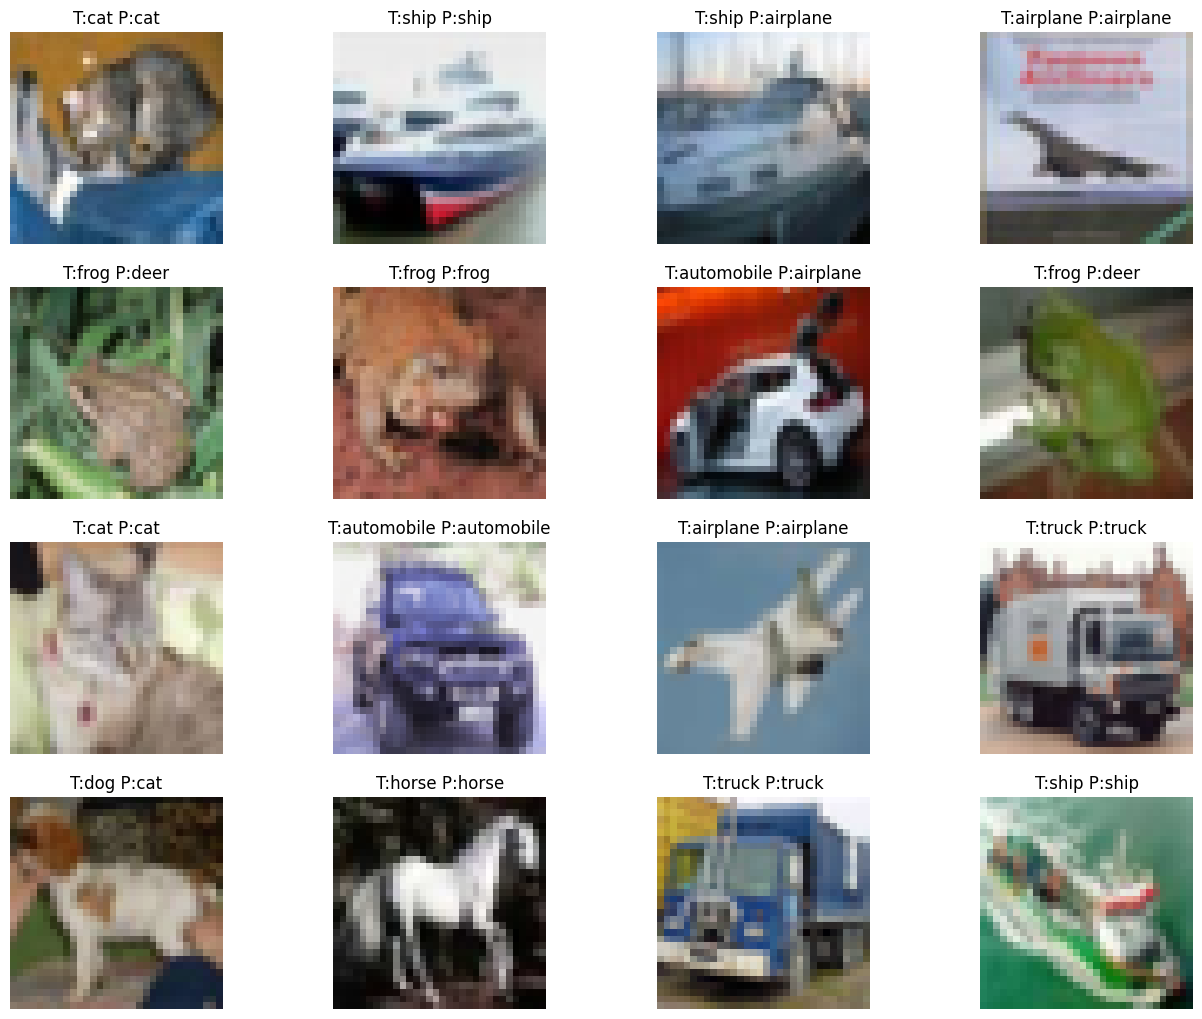

In [63]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]
def visualize(model,visualizer_loader, loader, n=5):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    preds = model(x).argmax(dim=1)
    x, y = next(iter(visualizer_loader))
    x, y = x.to(device), y.to(device)
    plt.figure(figsize=(16,16))
    for i in range(n):
        plt.subplot(n//4+1, 4, i+1)
        plt.imshow(x[i].cpu().squeeze().permute(1,2,0))
        plt.title(f"T:{class_names[y[i]]} P:{class_names[preds[i]]}")
        plt.axis('off')
    plt.show()
visualize(model,test_visualizer_loader,test_loader,16)

In [64]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(1024,256),
    nn.ReLU(),
    nn.Linear(256,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1148.4766
Training Accuracy
Accuracy: 56.27
Testing Accuracy
Accuracy: 54.43
Epoch 2
Loss : 817.2215
Training Accuracy
Accuracy: 68.43
Testing Accuracy
Accuracy: 65.60
Epoch 3
Loss : 669.0027
Training Accuracy
Accuracy: 74.47
Testing Accuracy
Accuracy: 69.37
Epoch 4
Loss : 579.3642
Training Accuracy
Accuracy: 77.11
Testing Accuracy
Accuracy: 70.45
Epoch 5
Loss : 504.3423
Training Accuracy
Accuracy: 80.21
Testing Accuracy
Accuracy: 71.73
Epoch 6
Loss : 439.4523
Training Accuracy
Accuracy: 84.10
Testing Accuracy
Accuracy: 72.57
Epoch 7
Loss : 377.4006
Training Accuracy
Accuracy: 85.75
Testing Accuracy
Accuracy: 72.17
Epoch 8
Loss : 326.3020
Training Accuracy
Accuracy: 90.04
Testing Accuracy
Accuracy: 73.17
Epoch 9
Loss : 273.7387
Training Accuracy
Accuracy: 90.65
Testing Accuracy
Accuracy: 72.33
Epoch 10
Loss : 231.6218
Training Accuracy
Accuracy: 93.89
Testing Accuracy
Accuracy: 72.80
Epoch 11
Loss : 189.9351
Training Accuracy
Accuracy: 93.69
Testing Accuracy
Accuracy: 72

KeyboardInterrupt: 

In [ ]:
#BEST MODEL 74%

In [65]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,16,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(1024,256),
    nn.ReLU(),
    nn.Linear(256,64),
    nn.ReLU(),
    nn.Linear(64,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1220.9591
Training Accuracy
Accuracy: 55.12
Testing Accuracy
Accuracy: 53.93
Epoch 2
Loss : 882.4550
Training Accuracy
Accuracy: 64.98
Testing Accuracy
Accuracy: 62.54
Epoch 3
Loss : 740.3107
Training Accuracy
Accuracy: 70.81
Testing Accuracy
Accuracy: 67.47
Epoch 4
Loss : 648.8471
Training Accuracy
Accuracy: 74.75
Testing Accuracy
Accuracy: 69.13
Epoch 5
Loss : 571.3648
Training Accuracy
Accuracy: 78.42
Testing Accuracy
Accuracy: 71.74
Epoch 6
Loss : 502.3132
Training Accuracy
Accuracy: 80.79
Testing Accuracy
Accuracy: 71.82
Epoch 7
Loss : 441.7780
Training Accuracy
Accuracy: 82.06
Testing Accuracy
Accuracy: 71.92
Epoch 8
Loss : 391.4650
Training Accuracy
Accuracy: 85.91
Testing Accuracy
Accuracy: 73.16
Epoch 9
Loss : 342.7299
Training Accuracy
Accuracy: 87.84
Testing Accuracy
Accuracy: 73.63
Epoch 10
Loss : 301.4405
Training Accuracy
Accuracy: 87.65
Testing Accuracy
Accuracy: 72.52


KeyboardInterrupt: 

In [68]:
#BEST MODEL 78%

In [67]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1363.9722
Training Accuracy
Accuracy: 48.67
Testing Accuracy
Accuracy: 48.76
Epoch 2
Loss : 1056.5182
Training Accuracy
Accuracy: 59.42
Testing Accuracy
Accuracy: 58.30
Epoch 3
Loss : 917.6289
Training Accuracy
Accuracy: 64.50
Testing Accuracy
Accuracy: 62.98
Epoch 4
Loss : 825.4297
Training Accuracy
Accuracy: 70.25
Testing Accuracy
Accuracy: 68.62
Epoch 5
Loss : 758.5590
Training Accuracy
Accuracy: 72.38
Testing Accuracy
Accuracy: 70.02
Epoch 6
Loss : 709.3516
Training Accuracy
Accuracy: 74.84
Testing Accuracy
Accuracy: 72.09
Epoch 7
Loss : 673.3822
Training Accuracy
Accuracy: 76.60
Testing Accuracy
Accuracy: 73.74
Epoch 8
Loss : 642.0317
Training Accuracy
Accuracy: 77.05
Testing Accuracy
Accuracy: 73.36
Epoch 9
Loss : 615.5478
Training Accuracy
Accuracy: 79.10
Testing Accuracy
Accuracy: 75.52
Epoch 10
Loss : 600.1091
Training Accuracy
Accuracy: 79.32
Testing Accuracy
Accuracy: 75.39
Epoch 11
Loss : 581.5990
Training Accuracy
Accuracy: 80.64
Testing Accuracy
Accuracy: 7

In [ ]:
#Best Model with 80%

In [69]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,128),
    nn.ReLU(),
    # nn.Dropout(0.4),
    # nn.Linear(256,64),
    # nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,40)
test_model(model,test_loader)

Epoch 1
Loss : 1329.4949
Training Accuracy
Accuracy: 52.09
Testing Accuracy
Accuracy: 52.23
Epoch 2
Loss : 1028.4046
Training Accuracy
Accuracy: 61.98
Testing Accuracy
Accuracy: 61.03
Epoch 3
Loss : 885.6642
Training Accuracy
Accuracy: 68.24
Testing Accuracy
Accuracy: 66.28
Epoch 4
Loss : 797.8341
Training Accuracy
Accuracy: 71.94
Testing Accuracy
Accuracy: 69.41
Epoch 5
Loss : 739.4497
Training Accuracy
Accuracy: 72.45
Testing Accuracy
Accuracy: 70.95
Epoch 6
Loss : 697.2256
Training Accuracy
Accuracy: 76.44
Testing Accuracy
Accuracy: 73.80
Epoch 7
Loss : 662.4278
Training Accuracy
Accuracy: 76.69
Testing Accuracy
Accuracy: 73.50
Epoch 8
Loss : 625.9613
Training Accuracy
Accuracy: 78.55
Testing Accuracy
Accuracy: 75.15
Epoch 9
Loss : 613.4714
Training Accuracy
Accuracy: 79.45
Testing Accuracy
Accuracy: 75.91
Epoch 10
Loss : 592.3379
Training Accuracy
Accuracy: 80.95
Testing Accuracy
Accuracy: 76.55
Epoch 11
Loss : 572.5241
Training Accuracy
Accuracy: 81.87
Testing Accuracy
Accuracy: 7

KeyboardInterrupt: 

In [1]:
#BEST MODEL WITH 86.77

In [74]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,128),
    nn.ReLU(),
    # nn.Dropout(0.4),
    # nn.Linear(256,64),
    # nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.5),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,30)
test_model(model,test_loader)

Epoch 1
Loss : 1076.4506
Training Accuracy
Accuracy: 66.18
Testing Accuracy
Accuracy: 65.13
Epoch 2
Loss : 742.4106
Training Accuracy
Accuracy: 75.20
Testing Accuracy
Accuracy: 72.81
Epoch 3
Loss : 625.7364
Training Accuracy
Accuracy: 78.45
Testing Accuracy
Accuracy: 76.08
Epoch 4
Loss : 559.1993
Training Accuracy
Accuracy: 81.81
Testing Accuracy
Accuracy: 78.43
Epoch 5
Loss : 506.0623
Training Accuracy
Accuracy: 85.07
Testing Accuracy
Accuracy: 81.33
Epoch 6
Loss : 469.5880
Training Accuracy
Accuracy: 86.37
Testing Accuracy
Accuracy: 82.01
Epoch 7
Loss : 443.6791
Training Accuracy
Accuracy: 87.73
Testing Accuracy
Accuracy: 82.73
Epoch 8
Loss : 414.5677
Training Accuracy
Accuracy: 89.24
Testing Accuracy
Accuracy: 83.78
Epoch 9
Loss : 391.4095
Training Accuracy
Accuracy: 89.83
Testing Accuracy
Accuracy: 83.66
Epoch 10
Loss : 378.4496
Training Accuracy
Accuracy: 90.49
Testing Accuracy
Accuracy: 84.35
Epoch 11
Loss : 362.5232
Training Accuracy
Accuracy: 91.47
Testing Accuracy
Accuracy: 84

In [13]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,128),
    nn.ReLU(),
    # nn.Dropout(0.4),
    # nn.Linear(256,64),
    # nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.5),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,30)
test_model(model,test_loader)

Epoch 1
Loss : 1083.3852
Training Accuracy
Accuracy: 67.60
Testing Accuracy
Accuracy: 66.10
Epoch 2
Loss : 728.7124
Training Accuracy
Accuracy: 73.63
Testing Accuracy
Accuracy: 71.78
Epoch 3
Loss : 611.1607
Training Accuracy
Accuracy: 80.64
Testing Accuracy
Accuracy: 78.01
Epoch 4
Loss : 547.8743
Training Accuracy
Accuracy: 83.58
Testing Accuracy
Accuracy: 79.91
Epoch 5
Loss : 495.4609
Training Accuracy
Accuracy: 85.27
Testing Accuracy
Accuracy: 80.81
Epoch 6
Loss : 460.2566
Training Accuracy
Accuracy: 85.89
Testing Accuracy
Accuracy: 81.11
Epoch 7
Loss : 430.9472
Training Accuracy
Accuracy: 87.81
Testing Accuracy
Accuracy: 82.27
Epoch 8
Loss : 409.2027
Training Accuracy
Accuracy: 89.03
Testing Accuracy
Accuracy: 82.79
Epoch 9
Loss : 392.2877
Training Accuracy
Accuracy: 90.14
Testing Accuracy
Accuracy: 83.91
Epoch 10
Loss : 368.8599
Training Accuracy
Accuracy: 91.19
Testing Accuracy
Accuracy: 84.59
Epoch 11
Loss : 357.7252
Training Accuracy
Accuracy: 91.59
Testing Accuracy
Accuracy: 84

In [14]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,128),
    nn.ReLU(),
    # nn.Dropout(0.4),
    # nn.Linear(256,64),
    # nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.5),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Linear(64,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,30)
test_model(model,test_loader)

Epoch 1
Loss : 1114.4250
Training Accuracy
Accuracy: 63.12
Testing Accuracy
Accuracy: 62.85
Epoch 2
Loss : 781.7085
Training Accuracy
Accuracy: 72.65
Testing Accuracy
Accuracy: 70.79
Epoch 3
Loss : 677.9386
Training Accuracy
Accuracy: 77.95
Testing Accuracy
Accuracy: 75.93
Epoch 4
Loss : 585.8314
Training Accuracy
Accuracy: 81.87
Testing Accuracy
Accuracy: 78.50
Epoch 5
Loss : 539.7185
Training Accuracy
Accuracy: 83.31
Testing Accuracy
Accuracy: 79.27
Epoch 6
Loss : 501.4564
Training Accuracy
Accuracy: 85.15
Testing Accuracy
Accuracy: 80.64
Epoch 7
Loss : 469.7391
Training Accuracy
Accuracy: 86.92
Testing Accuracy
Accuracy: 81.75
Epoch 8
Loss : 436.6566
Training Accuracy
Accuracy: 87.77
Testing Accuracy
Accuracy: 82.45
Epoch 9
Loss : 421.1971
Training Accuracy
Accuracy: 88.70
Testing Accuracy
Accuracy: 82.59
Epoch 10
Loss : 398.6758
Training Accuracy
Accuracy: 89.88
Testing Accuracy
Accuracy: 83.53
Epoch 11
Loss : 380.1704
Training Accuracy
Accuracy: 90.68
Testing Accuracy
Accuracy: 84

KeyboardInterrupt: 

In [12]:
#Augmentation
from torchvision.transforms import v2
augmentation_transform=v2.Compose([v2.RandomResizedCrop(size=(32,32),antialias=True),
                                           v2.RandomHorizontalFlip(p=0.2),
                                            v2.ToDtype(torch.float32, scale=True)
                                           ])
def augment_train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,epochs=5,lr_scheduler=None):
  for epoch in range(epochs):
    model.train()
    total_loss=0
    for x,y in train_loader:
      x=augmentation_transform(x)
      x,y=x.to(device),y.to(device)
      optimizer.zero_grad()
      logits=model(x)
      loss=loss_fn(logits,y)
      loss.backward()
      optimizer.step()
      total_loss+=loss.item()
    if lr_scheduler!=None:
        lr_scheduler.step()
    print(f"Epoch {epoch+1}")
    print(f"Loss : {total_loss:.4f}")
    print("Training Accuracy")
    train_accuracy.append(test_model(model,train_loader))
    print("Testing Accuracy")
    test_accuracy.append(test_model(model,test_loader))
def test_model(model,test_loader):
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for x,y in test_loader:
      x,y=x.to(device),y.to(device)
      logits=model(x)
      pred=logits.argmax(dim=1)
      correct+=(pred==y).sum().item()
      total+=y.size(0)
  print(f"Accuracy: {100*correct/total :.2f}")
  return 100*correct/total


In [17]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,256),
    nn.ReLU(),
    # nn.Dropout(0.4),
    # nn.Linear(256,64),
    # nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.5),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.5),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
augment_train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,100)
test_model(model,test_loader)

Epoch 1
Loss : 1443.6247
Training Accuracy
Accuracy: 42.37
Testing Accuracy
Accuracy: 42.20
Epoch 2
Loss : 1212.8077
Training Accuracy
Accuracy: 49.98
Testing Accuracy
Accuracy: 49.79
Epoch 3
Loss : 1128.7448
Training Accuracy
Accuracy: 54.44
Testing Accuracy
Accuracy: 54.22
Epoch 4
Loss : 1075.8238
Training Accuracy
Accuracy: 56.64
Testing Accuracy
Accuracy: 56.19
Epoch 5
Loss : 1008.9852
Training Accuracy
Accuracy: 56.82
Testing Accuracy
Accuracy: 56.21
Epoch 6
Loss : 986.4266
Training Accuracy
Accuracy: 59.96
Testing Accuracy
Accuracy: 59.54
Epoch 7
Loss : 955.5945
Training Accuracy
Accuracy: 56.18
Testing Accuracy
Accuracy: 55.16
Epoch 8
Loss : 927.9026
Training Accuracy
Accuracy: 59.30
Testing Accuracy
Accuracy: 58.08
Epoch 9
Loss : 888.0930
Training Accuracy
Accuracy: 60.89
Testing Accuracy
Accuracy: 59.76
Epoch 10
Loss : 889.5548
Training Accuracy
Accuracy: 67.12
Testing Accuracy
Accuracy: 65.76
Epoch 11
Loss : 853.0878
Training Accuracy
Accuracy: 62.07
Testing Accuracy
Accuracy

76.45

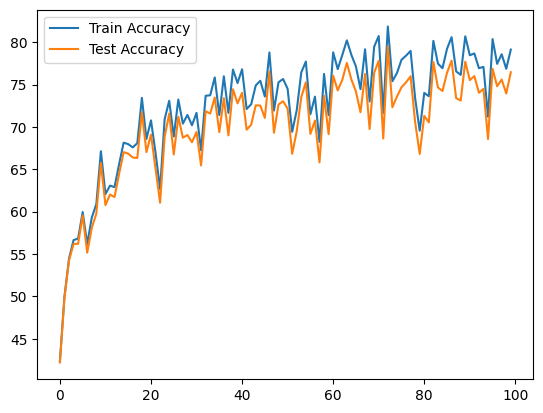

In [28]:
plt.plot(train_accuracy,label="Train Accuracy")
plt.plot(test_accuracy,label="Test Accuracy")
plt.legend()
plt.show()

In [29]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32,32,3,padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.25),
    nn.Conv2d(32,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.25),
    nn.Conv2d(64,128,3,padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(128,128,3,padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    # nn.Dropout(0.4),
    # nn.Linear(256,64),
    # nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256,128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
augment_train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,100)
test_model(model,test_loader)
#Try Scheduling

Epoch 1
Loss : 1387.7534
Training Accuracy
Accuracy: 38.51
Testing Accuracy
Accuracy: 38.26
Epoch 2
Loss : 1177.4967
Training Accuracy
Accuracy: 48.77
Testing Accuracy
Accuracy: 47.79
Epoch 3
Loss : 1105.4767
Training Accuracy
Accuracy: 52.39
Testing Accuracy
Accuracy: 52.40
Epoch 4
Loss : 1035.7063
Training Accuracy
Accuracy: 52.29
Testing Accuracy
Accuracy: 51.24
Epoch 5
Loss : 993.8669
Training Accuracy
Accuracy: 48.87
Testing Accuracy
Accuracy: 47.98
Epoch 6
Loss : 968.0710
Training Accuracy
Accuracy: 50.81
Testing Accuracy
Accuracy: 50.01
Epoch 7
Loss : 922.5024
Training Accuracy
Accuracy: 57.42
Testing Accuracy
Accuracy: 56.39
Epoch 8
Loss : 910.8140
Training Accuracy
Accuracy: 54.48
Testing Accuracy
Accuracy: 53.52
Epoch 9
Loss : 894.2258
Training Accuracy
Accuracy: 54.57
Testing Accuracy
Accuracy: 53.91
Epoch 10
Loss : 882.5036
Training Accuracy
Accuracy: 57.38
Testing Accuracy
Accuracy: 56.26
Epoch 11
Loss : 856.5362
Training Accuracy
Accuracy: 65.36
Testing Accuracy
Accuracy:

78.09

In [ ]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32,32,3,padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.25),
    nn.Conv2d(32,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.25),
    nn.Conv2d(64,128,3,padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(128,128,3,padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(128,128,3,padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    # nn.Dropout(0.4),
    # nn.Linear(256,64),
    # nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256,128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_accuracy=[]
test_accuracy=[]
augment_train_model(model,train_loader,test_loader,optimizer,loss_fn,train_accuracy,test_accuracy,epochs=100)
test_model(model,test_loader)
#Try Scheduling

Epoch 1
Loss : 1371.2160
Training Accuracy
Accuracy: 38.79
Testing Accuracy
Accuracy: 38.11
Epoch 2
Loss : 1180.6321
Training Accuracy
Accuracy: 46.36
Testing Accuracy
Accuracy: 45.85
Epoch 3
Loss : 1083.5008
Training Accuracy
Accuracy: 51.51
Testing Accuracy
Accuracy: 51.22
Epoch 4
Loss : 1035.1807
Training Accuracy
Accuracy: 49.65
Testing Accuracy
Accuracy: 48.89
Epoch 5
Loss : 1006.0120
Training Accuracy
Accuracy: 55.46
Testing Accuracy
Accuracy: 54.64
Epoch 6
Loss : 953.0508
Training Accuracy
Accuracy: 61.47
Testing Accuracy
Accuracy: 60.25
Epoch 7
Loss : 921.6968
Training Accuracy
Accuracy: 55.27
Testing Accuracy
Accuracy: 54.24
Epoch 8
Loss : 897.3049
Training Accuracy
Accuracy: 60.98
Testing Accuracy
Accuracy: 60.01
Epoch 9
Loss : 873.2736
Training Accuracy
Accuracy: 63.97
Testing Accuracy
Accuracy: 62.71
Epoch 10
Loss : 842.3151
Training Accuracy
Accuracy: 64.22
Testing Accuracy
Accuracy: 62.64
Epoch 11
Loss : 819.8629
Training Accuracy
Accuracy: 69.07
Testing Accuracy
Accuracy